## Goal: Find the 'peak' hours of demand for Med Center Express

### Background:

With the opening of the new University Hospital tower, there has been some issues with capacity at various times on med center express. Ultimately approximately 20,000 more riders are present on the med center express loop and demand may have moved times with new shifts in the tower. 

### Notes:
- The 9am hour (which is post current peak morning service) has had overcrowding
- In previous analysis it has been found that the ~3pm hour has been identified as an overly crowded time.
- This analysis is done with data subset from 4/1/2026 - 4/15/2026
- This is limited by accuracy of the APCs
- No data exists for people 'waiting' for a bus to my knowledge
- This is descriptive of past events and does not necessarily predict future patterns


In [1]:
# original data (4/1/2026 - 4/15/2026) is additionally stored in K:/AP/TTM/Data/WMC_Dashboard/analysis_data
import sys
import os

# go up one level from notebook folder
sys.path.append(os.path.abspath(".."))

from modules import med_center_dashboard as mcd

apr_mc_df = mcd.process_mc_busstate(year="2026", month="APR")

apr_mc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18560 entries, 0 to 18559
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   BUS_ID      18560 non-null  int64          
 1   DATE        18560 non-null  datetime64[us] 
 2   COUNT       18560 non-null  int64          
 3   STOP_ID     18560 non-null  int64          
 4   BOARDINGS   18560 non-null  int64          
 5   ALIGHTINGS  18560 non-null  int64          
 6   LOAD        18560 non-null  int64          
 7   RUN_ID      18560 non-null  float64        
 8   DEST        18560 non-null  str            
 9   ARRIVAL     18560 non-null  datetime64[us] 
 10  DEPARTURE   18560 non-null  datetime64[us] 
 11  DWELL       18560 non-null  timedelta64[us]
 12  HOUR        18560 non-null  int32          
 13  MINUTE      18560 non-null  int32          
dtypes: datetime64[us](3), float64(1), int32(2), int64(6), str(1), timedelta64[us](1)
memory usage: 1.8 MB


### NOTE:
- Using University Hospital and Doan Hall stops to determine demand
- If carmack lot stops should be included, come back here to edit

In [2]:
# cut down to only doan 37 and UH 401
# should now only have info for UH and Doan stops
uh_doan_apr_mc_df = apr_mc_df[(apr_mc_df['STOP_ID'] == 401) | (apr_mc_df['STOP_ID'] == 37)]

uh_doan_apr_mc_df

,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,LOAD,RUN_ID,DEST,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE
4,1303,2026-04-01,5,401,22,2,27,1503.0,MC,1900-01-01 14:06:59,1900-01-01 14:08:18,0 days 00:01:19,14,6
5,1303,2026-04-01,6,37,13,8,32,1503.0,MC,1900-01-01 14:08:51,1900-01-01 14:11:46,0 days 00:02:55,14,8
10,1303,2026-04-01,11,401,11,13,15,1503.0,MC,1900-01-01 14:30:21,1900-01-01 14:32:22,0 days 00:02:01,14,30
11,1303,2026-04-01,12,37,8,7,14,1503.0,MC,1900-01-01 14:32:57,1900-01-01 14:34:21,0 days 00:01:24,14,32
16,1303,2026-04-01,17,401,3,7,5,1503.0,MC,1900-01-01 14:53:41,1900-01-01 14:54:31,0 days 00:00:50,14,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18545,2503,2026-04-14,18536,37,6,1,11,1507.0,MC,1900-01-01 19:08:34,1900-01-01 19:11:40,0 days 00:03:06,19,8
18550,2503,2026-04-14,18541,401,38,2,38,1507.0,MC,1900-01-01 19:28:42,1900-01-01 19:30:23,0 days 00:01:41,19,28
18551,2503,2026-04-14,18542,37,5,1,42,1507.0,MC,1900-01-01 19:30:54,1900-01-01 19:33:39,0 days 00:02:45,19,30
18556,2503,2026-04-14,18547,401,6,1,5,1507.0,MC,1900-01-01 19:49:48,1900-01-01 19:50:46,0 days 00:00:58,19,49


In [3]:
# import visualization libraries
#%pip install seaborn matplotlib

import seaborn as sns
import matplotlib.pyplot as plt 

In [4]:
# cut down sample data to date, time of arrival, stop, boardings, and alightings 
import pandas as pd

temp = uh_doan_apr_mc_df[['DATE', 'ARRIVAL', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS']]

# combine date and arrival time to single col
temp['TIME'] = pd.to_datetime(temp['DATE'].astype(str) + ' ' + temp['ARRIVAL'].dt.time.astype(str))

temp.drop(['ARRIVAL'], axis=1, inplace=True)

# true 30 min buckets to determine peak periods
temp['BUCKET'] = temp['TIME'].dt.floor('30min').dt.strftime('%H:%M')

mc_df = temp.copy()

# create a 'net' colum as boardings - alightings
# directional, negative indicates bus 'emptying' passengers, positive indicates bus 'filling' passengers
mc_df = temp.copy()
mc_df['NET'] = mc_df['BOARDINGS'] - mc_df['ALIGHTINGS'] # net indicates PER STOP

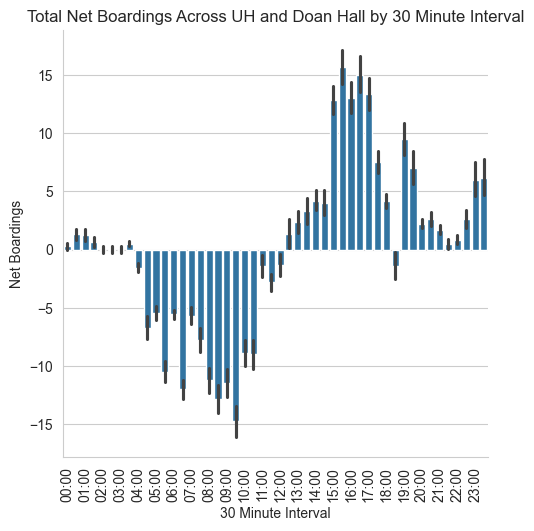

In [5]:
mc_df = mc_df.sort_values(by = "BUCKET")

sns.set_style("whitegrid")
# Plot in chronological order
plot = sns.catplot(
    data = mc_df,
    x = 'BUCKET',
    y = 'NET',
    #hue = 'BUCKET',
    kind = 'bar',
    #palette = "viridis"
)
plot.set(title = "Total Net Boardings Across UH and Doan Hall by 30 Minute Interval") # Negative indicates passengers inbound, Positive indicates passengers outbound
plot.set_axis_labels("30 Minute Interval", "Net Boardings")
plt.xticks(rotation=90, ticks=range(0, len(mc_df['BUCKET'].unique()), 2))
plt.show()

In [60]:
# Add all the stops to one DF
# apr_mc_df

temp = apr_mc_df[['DATE', 'ARRIVAL', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS']]

# combine date and arrival time to single col
temp['TIME'] = pd.to_datetime(temp['DATE'].astype(str) + ' ' + temp['ARRIVAL'].dt.time.astype(str))

temp.drop(['ARRIVAL'], axis=1, inplace=True)

# true 30 min buckets to determine peak periods
temp['BUCKET'] = temp['TIME'].dt.floor('30min').dt.strftime('%H:%M')

mc_df = temp.copy()

# create a 'net' colum as boardings - alightings
# directional, negative indicates bus 'emptying' passengers, positive indicates bus 'filling' passengers
all_stops_df = temp.copy()
all_stops_df['NET'] = all_stops_df['BOARDINGS'] - all_stops_df['ALIGHTINGS'] # net indicates PER STOP

In [46]:
all_stops_df.sort_values(by = "TIME", inplace=True)
all_stops_df[all_stops_df['STOP_ID'] == 403]

,DATE,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET,TIME_BUCKET
5817,2026-04-01,403,0,0,2026-04-01 00:01:44,00:00,0,0-6am
3986,2026-04-01,403,0,1,2026-04-01 00:08:55,00:00,-1,0-6am
5823,2026-04-01,403,0,0,2026-04-01 00:23:54,00:00,0,0-6am
5829,2026-04-01,403,0,0,2026-04-01 00:40:40,00:30,0,0-6am
5835,2026-04-01,403,0,2,2026-04-01 01:00:33,01:00,-2,0-6am
...,...,...,...,...,...,...,...,...
5787,2026-04-16,403,0,0,2026-04-16 03:22:42,03:00,0,0-6am
5793,2026-04-16,403,0,1,2026-04-16 03:42:36,03:30,-1,0-6am
5799,2026-04-16,403,1,0,2026-04-16 04:03:30,04:00,1,0-6am
5805,2026-04-16,403,7,0,2026-04-16 04:23:36,04:00,7,0-6am


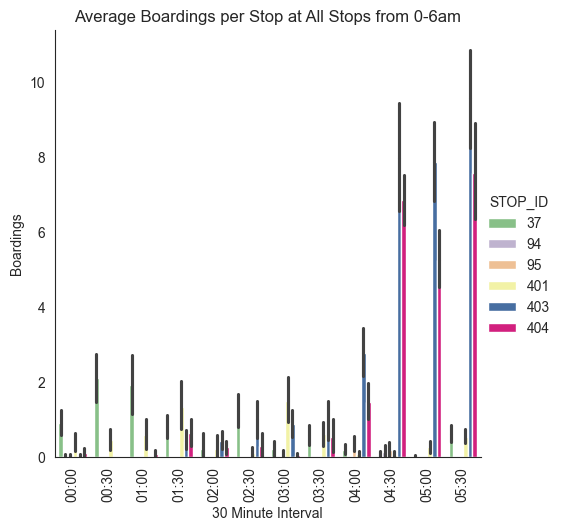

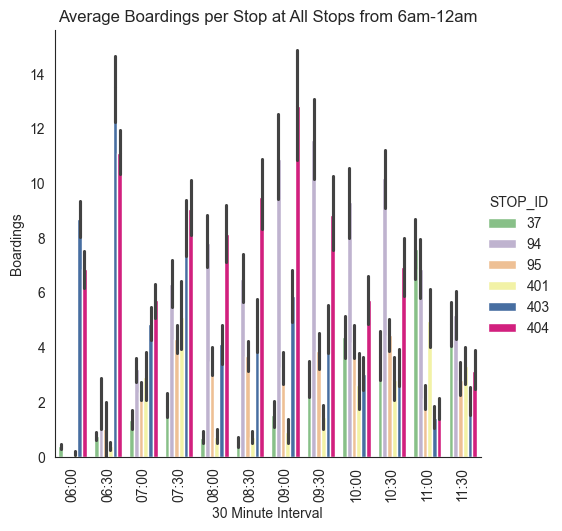

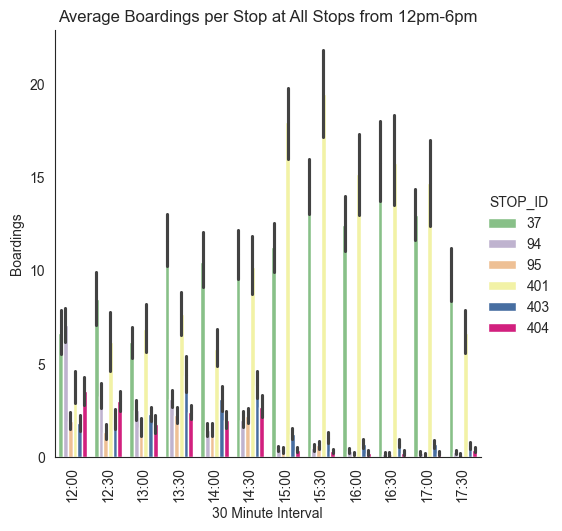

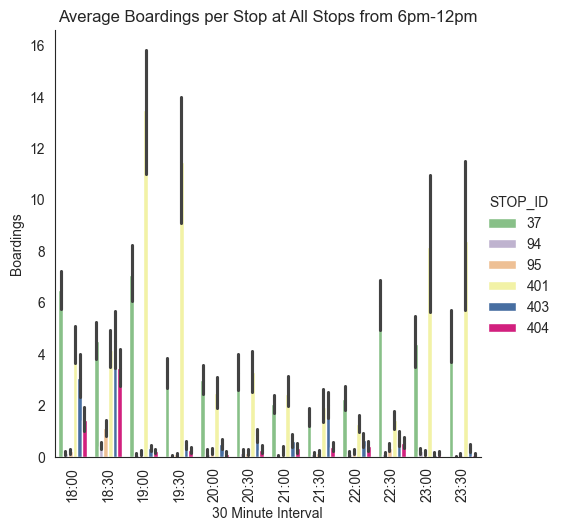

In [47]:
# Generate histogram of boardings at all stops

# Split into 0-6am, 6am-12am, 12pm-6pm, 6pm-12am
all_stops_df['TIME'] = pd.to_datetime(all_stops_df['TIME'])
all_stops_df['TIME_BUCKET'] = pd.cut(all_stops_df['TIME'].dt.hour, bins=[0, 6, 12, 18, 24], labels=['0-6am', '6am-12am', '12pm-6pm', '6pm-12pm'], right=False)

all_stops_df_0_6am = all_stops_df[all_stops_df['TIME_BUCKET'] == '0-6am'].sort_values(by = "BUCKET")
sns.catplot(data=all_stops_df_0_6am, x='BUCKET', y='BOARDINGS', hue='STOP_ID', palette="Accent", kind='bar')
plt.title("Average Boardings per Stop at All Stops from 0-6am")
plt.ylabel("Boardings")
plt.xlabel("30 Minute Interval")
plt.xticks(rotation=90)
plt.show()

all_stops_df_6_12am = all_stops_df[all_stops_df['TIME_BUCKET'] == '6am-12am'].sort_values(by = "BUCKET")
sns.catplot(data=all_stops_df_6_12am, x='BUCKET', y='BOARDINGS', hue='STOP_ID', palette="Accent", kind='bar')
plt.title("Average Boardings per Stop at All Stops from 6am-12am")
plt.ylabel("Boardings")
plt.xlabel("30 Minute Interval")
plt.xticks(rotation=90)
plt.show()

all_stops_df_12_6pm = all_stops_df[all_stops_df['TIME_BUCKET'] == '12pm-6pm'].sort_values(by = "BUCKET")
sns.catplot(data=all_stops_df_12_6pm, x='BUCKET', y='BOARDINGS', hue='STOP_ID', palette="Accent", kind='bar')
plt.title("Average Boardings per Stop at All Stops from 12pm-6pm")
plt.ylabel("Boardings")
plt.xlabel("30 Minute Interval")
plt.xticks(rotation=90)
plt.show()

all_stops_df_6_12pm = all_stops_df[all_stops_df['TIME_BUCKET'] == '6pm-12pm'].sort_values(by = "BUCKET")
sns.catplot(data=all_stops_df_6_12pm, x='BUCKET', y='BOARDINGS', hue='STOP_ID', palette="Accent", kind='bar')
plt.title("Average Boardings per Stop at All Stops from 6pm-12pm")
plt.ylabel("Boardings")
plt.xlabel("30 Minute Interval")
plt.xticks(rotation=90)
plt.show()

### Notes:
- Clear inbound vs outbound hours
- Inbound appears to peak from approximately 4am - 10am
- Outbound appears to peak from approximately 3pm - 8pm ish

In [68]:
uh_doan_mc_df = mc_df[mc_df['STOP_ID'].isin([37, 401])]
uh_doan_mc_df['NET'] = uh_doan_mc_df['BOARDINGS'] - uh_doan_mc_df['ALIGHTINGS']
uh_doan_mc_df.sort_values(by = "BUCKET", inplace=True)

In [73]:
# sort by time bucket and include the avg magnitude
table_df = (
    uh_doan_mc_df # already sorted by time bucket
    .groupby("BUCKET", as_index=False)[["NET", "BOARDINGS", "ALIGHTINGS"]].sum() # pos = outbound, neg = inbound
)

table_df

,BUCKET,NET,BOARDINGS,ALIGHTINGS
0,00:00,27,58,31
1,00:30,71,71,0
2,01:00,35,35,0
3,01:30,36,59,23
4,02:00,-1,6,7
5,02:30,1,37,36
6,03:00,0,24,24
7,03:30,28,33,5
8,04:00,-113,10,123
9,04:30,-464,4,468


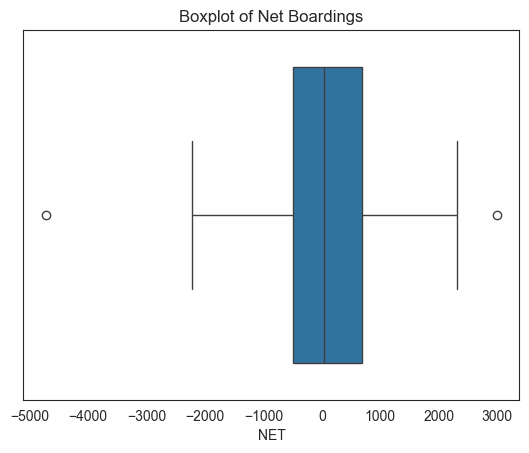

In [74]:
# boxplot both net and avg_magnitude
sns.set_style("white")

sns.boxplot(
    data = table_df,
    x = 'NET'
)
plt.title('Boxplot of Net Boardings')
plt.show()

C:\Users\morgan.1461\AppData\Local\Temp\ipykernel_26232\2700017600.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=table_df, x='BUCKET', y=np.abs(table_df['NET']), palette="viridis", kind='bar')


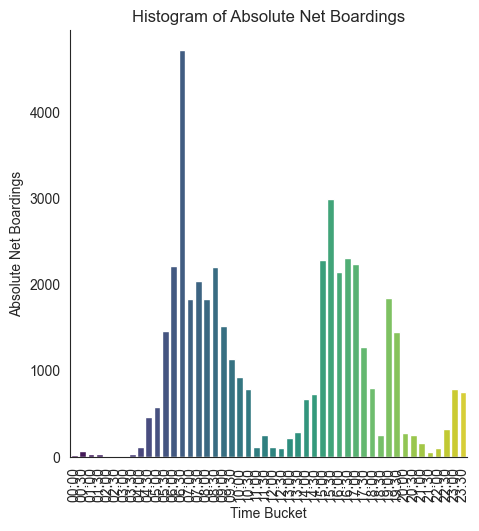

In [54]:
import numpy as np

sns.catplot(data=table_df, x='BUCKET', y=np.abs(table_df['NET']), palette="viridis", kind='bar')
plt.title('Histogram of Absolute Net Boardings')
plt.ylabel('Absolute Net Boardings')
plt.xlabel('Time Bucket')
plt.xticks(rotation=90)
plt.show()

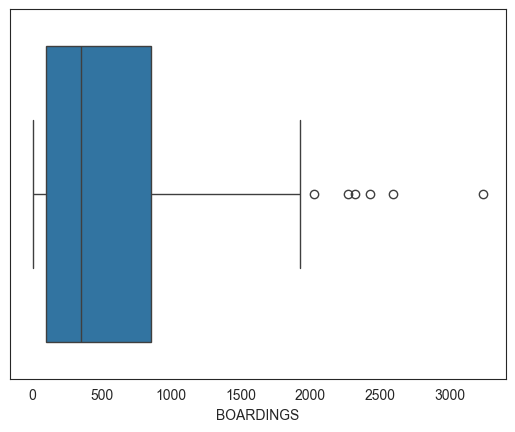

75th quantile for boardings: 852.0


In [76]:
# boxplot for boardings
sns.boxplot(
    data = table_df,
    x = 'BOARDINGS'
)
plt.show()
# calculate 75TH quantile for boardings
boardings_upper_quantile = np.percentile(table_df['BOARDINGS'], 75)
print(f'75th quantile for boardings: {boardings_upper_quantile}')

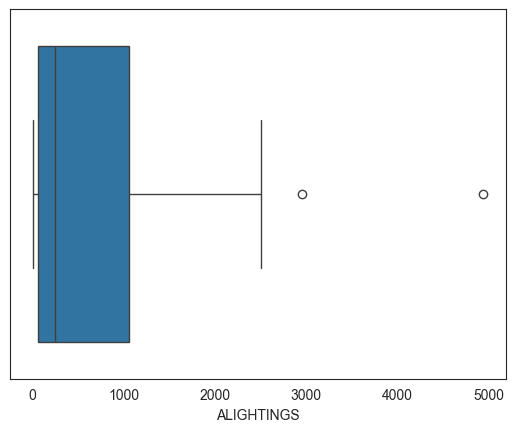

75th quantile for alightings: 1062.75


In [78]:
#boxplot for alightings
sns.boxplot(
    data = table_df,
    x = 'ALIGHTINGS'
)
plt.show()
# calculate 75TH quantile for alightings
alightings_upper_quantile = np.percentile(table_df['ALIGHTINGS'], 75)
print(f'75th quantile for alightings: {alightings_upper_quantile}')

In [79]:
# print out the times that are in the top 25% of boardings and alightings
top_boardings = table_df[table_df['BOARDINGS'] >= boardings_upper_quantile]
top_alightings = table_df[table_df['ALIGHTINGS'] >= alightings_upper_quantile]
print("Time buckets in the top 25% of boardings:")
print(top_boardings[['BUCKET', 'BOARDINGS']])
print("Time buckets in the top 25% of alightings:")
print(top_alightings[['BUCKET', 'ALIGHTINGS']])

Time buckets in the top 25% of boardings:
   BUCKET  BOARDINGS
15  07:30        909
28  14:00       1293
29  14:30       1928
30  15:00       2597
31  15:30       3244
32  16:00       2273
33  16:30       2431
34  17:00       2324
35  17:30       1394
36  18:00       1039
38  19:00       2027
39  19:30       1505
Time buckets in the top 25% of alightings:
   BUCKET  ALIGHTINGS
11  05:30        1541
12  06:00        2322
13  06:30        4944
14  07:00        2503
15  07:30        2949
16  08:00        1955
17  08:30        2317
18  09:00        1677
19  09:30        1301
20  10:00        1285
21  10:30        1077
29  14:30        1199


### NOTE:
- Based on the boxplots and histograms of the magnitude, there are two clear outliers one for IB and one for OB
- The peak magnitude times are:
    - 6:30am -> inbound
    - 3:30pm -> outbound (less strong)
- Methodology is that using the University Hospital (401) and Doan Hall (37) stops will be more accurate for these purposes.
    - Busses do not consistently stop at Carmack 5A and 5B stops, which could skew the data
    - This route acts as a shuttle, therefore every boarding/alighting at the UH/Doan stops should have an equal opposite boarding/alighting at Carmack.
- Approximately 14:00 -> 19:30 is peak outbound hours
    - Small boarding peak at 07:30, OK - overlaps with peak inbound hours
    - 18:30 hour drops below peak - just below at 803 boardings (threshold of 852) and 1058 alightings (threshold of 1062)
- Approximately 05:00 -> 10:30 is peak inbound hours
    - Additional small peak at 14:30 - overlaps with peak outbound hours


In [ ]:
# Less strict thresholds at the top and bottom quantiles
import numpy as np

# Since this is the total passenger flow, create an absolute value column to determine the magnitude of the flow regardless of direction
table_df['ABS_NET'] = np.abs(table_df['NET'])

# Calculate the top and bottom quantiles
bottom_quantile = np.percentile(table_df['ABS_NET'], 25)
top_quantile = np.percentile(table_df['ABS_NET'], 75)

print(f'Bottom quantile: {bottom_quantile}, top quantile: {top_quantile}')

# find timeframes in the top 25% of quantiles 
upper_quantile_times = table_df[(table_df['ABS_NET'] >= top_quantile)]
upper_quantile_times

Bottom quantile: 116.75, top quantile: 1593.25


,BUCKET,NET,ABS_NET
12,06:00,-2215,2215
13,06:30,-4718,4718
14,07:00,-1828,1828
15,07:30,-2040,2040
16,08:00,-1837,1837
17,08:30,-2209,2209
30,15:00,2283,2283
31,15:30,2994,2994
32,16:00,2151,2151
33,16:30,2311,2311


In [56]:
lower_quantile_times = table_df[(table_df['ABS_NET'] <= bottom_quantile)]
lower_quantile_times

,BUCKET,NET,ABS_NET
0,00:00,27,27
1,00:30,71,71
2,01:00,35,35
3,01:30,36,36
4,02:00,-1,1
5,02:30,1,1
6,03:00,0,0
7,03:30,28,28
8,04:00,-113,113
25,12:30,106,106


- 6am - 8:30am consist of 'peak" inbound hours, 3pm - 7pm are 'peak' outbound hours based on the quantile range


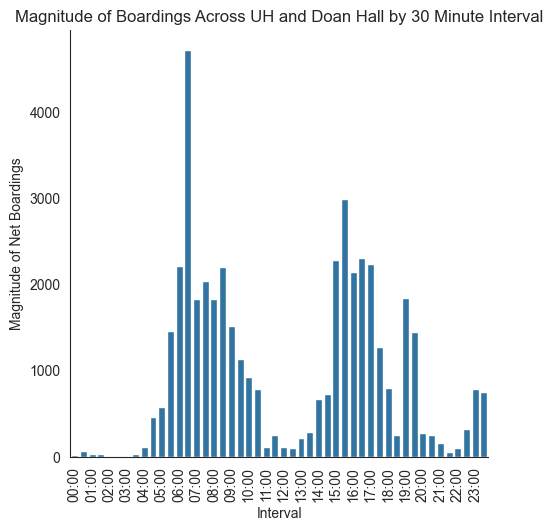

In [11]:
# plot the absolute value of passenger flow through UH/Doan stops
sns.catplot(
    data = table_df,
    x = 'BUCKET',
    y = table_df['NET'].abs(),
    kind = 'bar'
)
plt.title("Magnitude of Boardings Across UH and Doan Hall by 30 Minute Interval") # Negative indicates passengers inbound, Positive indicates passengers outbound
plt.xlabel("Interval")
plt.ylabel("Magnitude of Net Boardings")
plt.xticks(rotation=90, ticks=range(0, len(mc_df['BUCKET'].unique()), 2))
plt.show()

From this we can see 2 clear peaks, 1 in morning, and 1 in the evening, as expected.

In [13]:
# remove data from 4/16/2026
mc_df = mc_df[mc_df["DATE"] != "2026-04-16"]

# convert to datetime
work = mc_df.copy()
work["DATE"] = pd.to_datetime(work["DATE"])

# convert to table containing the boarding and alightings at each timeframe across each day
daily_bucket = (
    work.groupby(["DATE", "BUCKET"], as_index=False) # 30 min intervals for each day
        .agg( 
            BOARDINGS=("BOARDINGS", "sum"), # total boardings in 30 min interval across both stops
            ALIGHTINGS=("ALIGHTINGS", "sum"), # total alightings in 30 min interval across both stops
            NET=("NET", "sum") # i guess this is useful for understanding directionality of passenger flow?
        )
)
daily_bucket["ABS_NET"] = daily_bucket["NET"].abs() #abs value
daily_bucket

,DATE,BUCKET,BOARDINGS,ALIGHTINGS,NET,ABS_NET
0,2026-04-01,00:00,5,15,-10,10
1,2026-04-01,00:30,10,0,10,10
2,2026-04-01,01:00,2,0,2,2
3,2026-04-01,01:30,6,2,4,4
4,2026-04-01,02:00,0,0,0,0
...,...,...,...,...,...,...
541,2026-04-15,21:30,15,18,-3,3
542,2026-04-15,22:00,15,7,8,8
543,2026-04-15,22:30,48,11,37,37
544,2026-04-15,23:00,61,3,58,58


In [14]:
# Grouping the data by 30 min intervals, and taking median of each for a more robust measure of central tendency across the studied timeframe
peak_table = (
    daily_bucket.groupby("BUCKET", as_index=False)
        .agg(
            MED_BOARDINGS=("BOARDINGS", "median"), # median across all days bus ran at each 30 min interval
            #P75_BOARDINGS=("BOARDINGS", lambda s: np.percentile(s, 75)), # 75th percentile across all days bus ran at each 30 min interval
            P90_BOARDINGS=("BOARDINGS", lambda s: np.percentile(s, 90)), # 90th percentile across all days bus ran at each 30 min interval
            MED_ALIGHTINGS=("ALIGHTINGS", "median"),
            P90_ALIGHTINGS=("ALIGHTINGS", lambda s: np.percentile(s, 90)), # 90th percentile across all days bus ran at each 30 min interval
        )
        .sort_values("BUCKET")
)
peak_table

,BUCKET,MED_BOARDINGS,P90_BOARDINGS,MED_ALIGHTINGS,P90_ALIGHTINGS
0,00:00,5.0,7.0,1.0,4.0
1,00:30,5.0,8.8,0.0,0.0
2,01:00,2.0,3.8,0.0,0.0
3,01:30,5.0,6.0,2.0,2.8
4,02:00,0.0,1.8,0.0,1.8
5,02:30,2.0,4.0,2.0,4.0
6,03:00,1.0,3.8,2.0,3.0
7,03:30,2.0,4.8,0.0,1.0
8,04:00,1.0,1.8,10.0,12.8
9,04:30,0.0,1.0,42.0,45.8


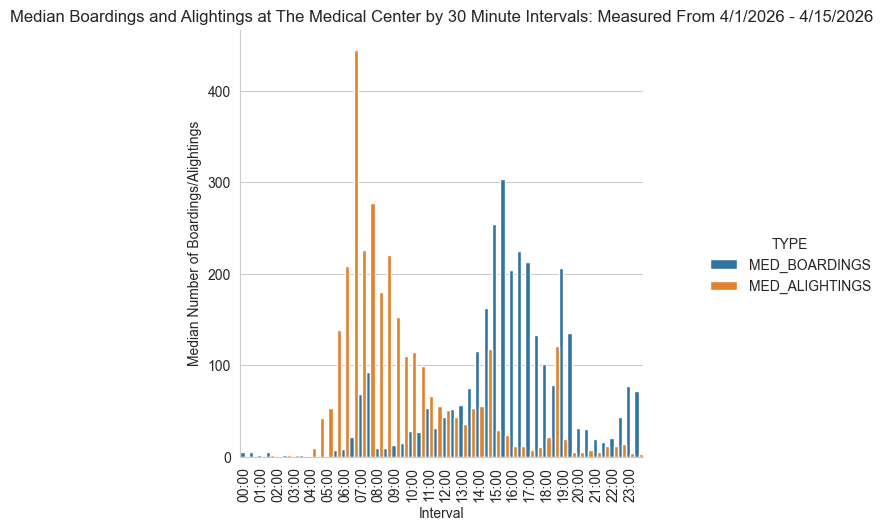

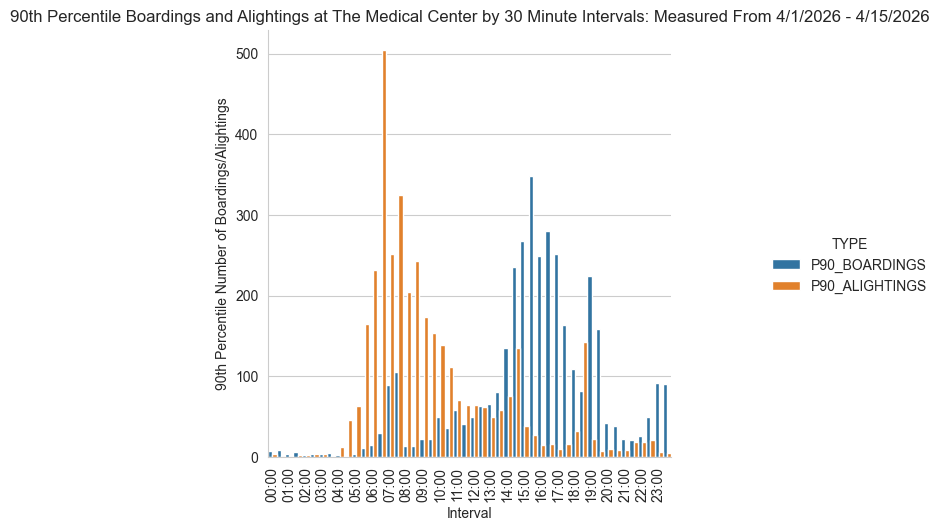

In [15]:
# combine together the med boardings and med alightings to plot these together
sns.set_style("whitegrid")

peak_long = peak_table.melt(
    id_vars="BUCKET",
    value_vars=["MED_BOARDINGS", "MED_ALIGHTINGS"],
    var_name="TYPE",
    value_name="VALUE"
)

sns.catplot(
    data=peak_long,
    x="BUCKET",
    y="VALUE",
    hue="TYPE",
    kind="bar",
    width=1
)

plt.title("Median Boardings and Alightings at The Medical Center by 30 Minute Intervals: Measured From 4/1/2026 - 4/15/2026") # Negative indicates passengers inbound, Positive indicates passengers outbound
plt.xlabel("Interval")
plt.ylabel("Median Number of Boardings/Alightings")
plt.xticks(rotation=90, ticks=range(0, len(mc_df['BUCKET'].unique()), 2))
plt.show()

# do the same for the 90th percentile to represent 'worst case scenario'
peak_long_90 = peak_table.melt(
    id_vars="BUCKET",
    value_vars=["P90_BOARDINGS", "P90_ALIGHTINGS"],
    var_name="TYPE",
    value_name="VALUE"
)

sns.catplot(
    data=peak_long_90,
    x="BUCKET",
    y="VALUE",
    hue="TYPE",
    kind="bar",
    width=1
)
plt.title("90th Percentile Boardings and Alightings at The Medical Center by 30 Minute Intervals: Measured From 4/1/2026 - 4/15/2026") # Negative indicates passengers inbound, Positive indicates passengers outbound
plt.xlabel("Interval")
plt.ylabel("90th Percentile Number of Boardings/Alightings")
plt.xticks(rotation=90, ticks=range(0, len(mc_df['BUCKET'].unique()), 2))
plt.show()

<Axes: xlabel='STOP_ID', ylabel='BUCKET'>

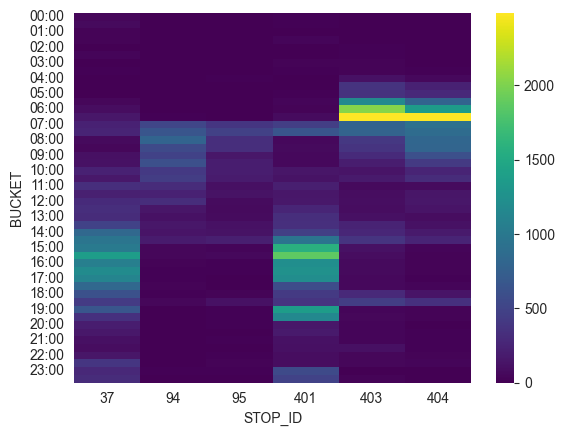

In [20]:
# go back and include the carmack stops too to get a more complete picture of the passenger flow through the medical center
temp = apr_mc_df[['DATE', 'ARRIVAL', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS']]

# combine date and arrival time to single col
temp['TIME'] = pd.to_datetime(temp['DATE'].astype(str) + ' ' + temp['ARRIVAL'].dt.time.astype(str))

temp.drop(['ARRIVAL'], axis=1, inplace=True)

# true 30 min buckets to determine peak periods
temp['BUCKET'] = temp['TIME'].dt.floor('30min').dt.strftime('%H:%M')

total_mc_df = temp.copy()

# Create a heatmap of boardings by stop and 30-min bucket
heatmap_data = total_mc_df.pivot_table(index='BUCKET', columns='STOP_ID', values='BOARDINGS', aggfunc='sum').fillna(0)
sns.heatmap(heatmap_data, cmap='viridis')

Going to base the "recommendations" on the 90th percentile as a conservative recommendation, this could be brought up to 95 to be more aggresive, or 100 if the goal is to always have enough capacity no matter what, based on last 2 weeks of data

In [145]:
# theoretical numbers
BUS_CAPACITY = 60 # from previous data it seems around 60 people will wait for the next bus
TARGET_LOAD = 0.85
effective_capacity = BUS_CAPACITY * TARGET_LOAD

peak_table["REQ_BUSES_PER_HALF_HOUR"] = np.ceil(
    peak_table[["P90_BOARDINGS", "P90_ALIGHTINGS"]].max(axis=1) / effective_capacity
).astype(int)

peak_table["RECOMMENDED_HEADWAY_MIN"] = 30 / peak_table["REQ_BUSES_PER_HALF_HOUR"].clip(lower=1)
peak_table

,BUCKET,MED_BOARDINGS,P90_BOARDINGS,MED_ALIGHTINGS,P90_ALIGHTINGS,REQ_BUSES_PER_HALF_HOUR,RECOMMENDED_HEADWAY_MIN
0,00:00,5.0,7.0,1.0,4.0,1,30.000000
1,00:30,5.0,8.8,0.0,0.0,1,30.000000
2,01:00,2.0,3.8,0.0,0.0,1,30.000000
3,01:30,5.0,6.0,2.0,2.8,1,30.000000
4,02:00,0.0,1.8,0.0,1.8,1,30.000000
5,02:30,2.0,4.0,2.0,4.0,1,30.000000
6,03:00,1.0,3.8,2.0,3.0,1,30.000000
7,03:30,2.0,4.8,0.0,1.0,1,30.000000
8,04:00,1.0,1.8,10.0,12.8,1,30.000000
9,04:30,0.0,1.0,42.0,45.8,1,30.000000


,BUCKET,MED_BOARDINGS,P75_BOARDINGS,P90_BOARDINGS,MED_ABS_NET,P90_ABS_NET,REQ_BUSES_PER_HALF_HOUR,RECOMMENDED_HEADWAY_MIN
0,00:00,5.0,6.5,7.0,3.0,9.0,1,30.000000
1,00:30,5.0,8.0,8.8,5.0,8.8,1,30.000000
2,01:00,2.0,3.0,3.8,2.0,3.8,1,30.000000
3,01:30,5.0,6.0,6.0,3.0,4.0,1,30.000000
4,02:00,0.0,0.0,1.8,0.0,2.0,1,30.000000
5,02:30,2.0,3.0,4.0,1.0,2.8,1,30.000000
6,03:00,1.0,3.0,3.8,1.0,2.0,1,30.000000
7,03:30,2.0,3.0,4.8,2.0,4.6,1,30.000000
8,04:00,1.0,1.0,1.8,9.0,11.8,1,30.000000
9,04:30,0.0,0.0,1.0,42.0,45.8,1,30.000000


### Methodology logic
busses per hour = peak_passengers_per_hour / (bus_capacity * target_load_factor)



---

### Defining "Peak" Hours

Breaking into a 3 faceted approach for each interval:

- Passenger Load
    - Effectively shows how full busses are over time
    - load = cumulative boardings - cumulative alightings AT A SINGLE STOP
- Boardings
    - Total boardings per stop at each half hour interval
- Alightings
    - Total alightings per stop at each half hour interval

In [25]:
# total_mc_df holds all data here
# 11 day sample size
# cutting out the 4/16/2026 data to be consistent with the other analyses, but can easily include this if needed
total_mc_df = total_mc_df[total_mc_df["DATE"] != "2026-04-16"]
# total timeframe is 4/1/2026 0000 - 4/15/2026 2400

total_mc_df.sort_values(by='BUCKET', inplace=True)
#total_mc_df.sort_values(by='TIME', inplace=True)
total_mc_df

,DATE,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET
11563,2026-04-01,94,0,1,2026-04-01 00:00:31,00:00
6170,2026-04-03,95,0,0,2026-04-03 00:25:31,00:00
2001,2026-04-03,37,1,0,2026-04-03 00:24:48,00:00
6169,2026-04-03,94,0,1,2026-04-03 00:24:27,00:00
6168,2026-04-03,404,0,0,2026-04-03 00:22:50,00:00
...,...,...,...,...,...,...
6778,2026-04-02,403,0,3,2026-04-02 23:51:58,23:30
11632,2026-04-02,37,1,0,2026-04-02 23:51:21,23:30
1993,2026-04-02,95,0,4,2026-04-02 23:51:06,23:30
6160,2026-04-02,37,1,0,2026-04-02 23:55:19,23:30


### NOTE:
- Since the med center shuttle does not consistently stop at the Carmack 5 lots, these are inconsistent datapoints
- Instead of analyzing the boardings at Carmack, analyzing the alightings at UH/Doan should be more accurate

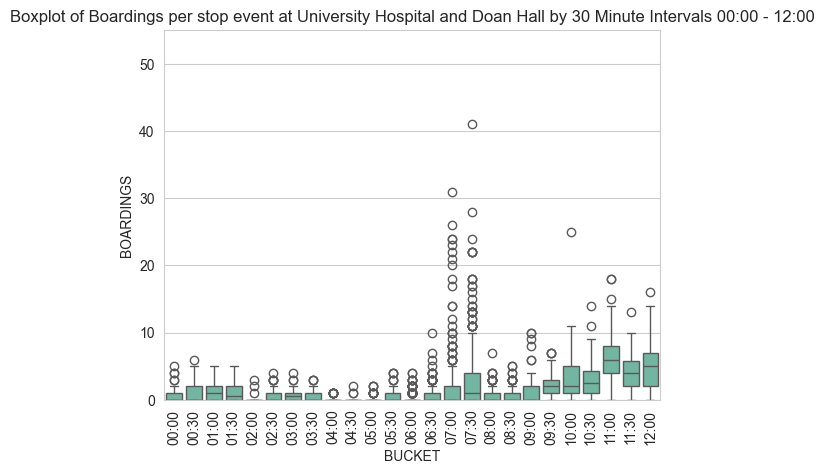

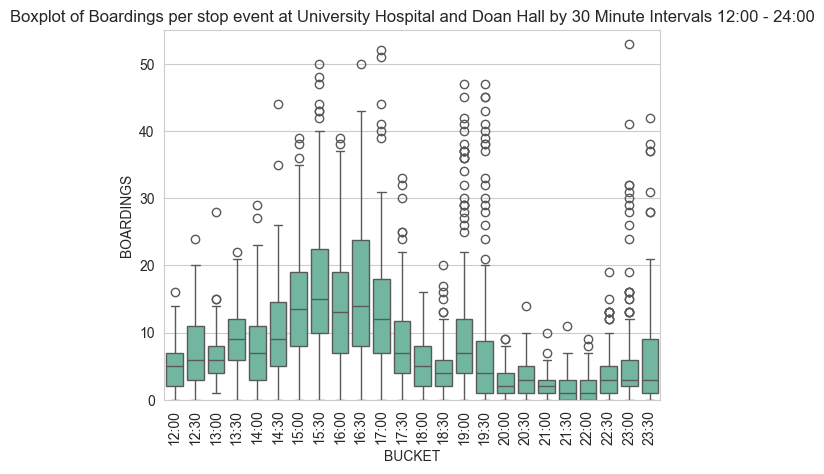

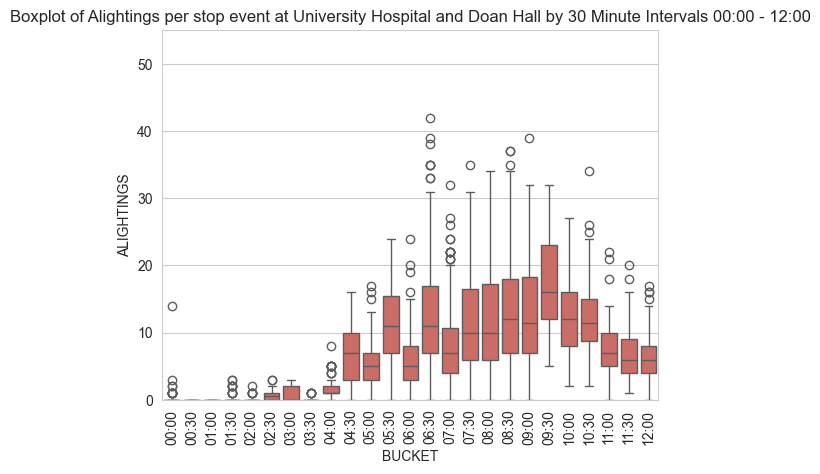

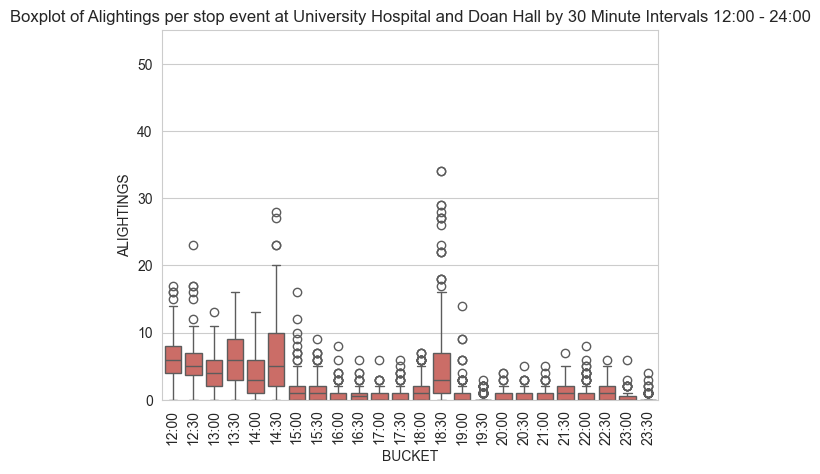

In [61]:
# boxplot of time buckets to see distribution of boardings and alightings across the studied timeframe
med_center_stops_df = total_mc_df[total_mc_df['STOP_ID'].isin([37, 401])]
carmack_stops_df = total_mc_df[total_mc_df['STOP_ID'].isin([403, 404, 95, 94])]

# split data into 2 groups to make boxplots easier to read
med_center_stops_df_00_12 = med_center_stops_df[med_center_stops_df['BUCKET'].between('00:00', '12:00')]
med_center_stops_df_12_24 = med_center_stops_df[med_center_stops_df['BUCKET'].between('12:00', '24:00')]
carmack_stops_df_00_12 = carmack_stops_df[carmack_stops_df['BUCKET'].between('00:00', '12:00')]
carmack_stops_df_12_24 = carmack_stops_df[carmack_stops_df['BUCKET'].between('12:00', '24:00')]

sns.set_style("whitegrid")

sns.set_palette("Set2")
g = sns.boxplot(
    data = med_center_stops_df_00_12,
    x = 'BUCKET',
    y = 'BOARDINGS'
)
g.set_ylim(0,55) # set y limit to make consistent across all boxplots for easier comparison
plt.title('Boxplot of Boardings per stop event at University Hospital and Doan Hall by 30 Minute Intervals 00:00 - 12:00')
plt.xticks(rotation=90)
plt.show()

g = sns.boxplot(
    data = med_center_stops_df_12_24,
    x = 'BUCKET',
    y = 'BOARDINGS'
)
g.set_ylim(0,55) # set y limit to make consistent across all boxplots for easier comparison
plt.title('Boxplot of Boardings per stop event at University Hospital and Doan Hall by 30 Minute Intervals 12:00 - 24:00')
plt.xticks(rotation=90)
plt.show()

# INSTEAD of boarding at carmack, alightings at UH/Doan will be more accurate as Carmack 5 is not always stopped at
sns.set_palette("hls", 1)
g = sns.boxplot(
    data = med_center_stops_df_00_12,
    x = 'BUCKET',
    y = 'ALIGHTINGS'
)
g.set_ylim(0,55) # set y limit to make consistent across all boxplots for easier comparison
plt.title('Boxplot of Alightings per stop event at University Hospital and Doan Hall by 30 Minute Intervals 00:00 - 12:00')
plt.xticks(rotation=90)
plt.show()

g = sns.boxplot(
    data = med_center_stops_df_12_24,
    x = 'BUCKET',
    y = 'ALIGHTINGS'
)
g.set_ylim(0,55) # set y limit to make consistent across all boxplots for easier comparison
plt.title('Boxplot of Alightings per stop event at University Hospital and Doan Hall by 30 Minute Intervals 12:00 - 24:00')
plt.xticks(rotation=90)
plt.show()

### Notes:
- These indicate the number of boardings at each stop event at these times.
- holup the CM5 stops will be weighing down the boardings for the carmack lots, therefore the alightings at UH/DOAN was used for this analysis

In [81]:
# Aggregatte boardings and alightings by 30 min interval
med_center_stops_sum_df = (
    med_center_stops_df
    .groupby("BUCKET", as_index=False)
    .agg(
        TOTAL_BOARDINGS=("BOARDINGS", "sum"),
        TOTAL_ALIGHTINGS=("ALIGHTINGS", "sum"),
        AVG_BOARDINGS=("BOARDINGS", "mean"),
        AVG_ALIGHTINGS=("ALIGHTINGS", "mean")
    )
)

# compute some potentially intersting metrics
med_center_stops_sum_df['AVG_NET'] = med_center_stops_sum_df['AVG_BOARDINGS'] - med_center_stops_sum_df['AVG_ALIGHTINGS'] # per day
med_center_stops_sum_df['TOTAL_NET'] = med_center_stops_sum_df['TOTAL_BOARDINGS'] - med_center_stops_sum_df['TOTAL_ALIGHTINGS'] # across all days, directional
med_center_stops_sum_df['CUMULATIVE_LOAD'] = med_center_stops_sum_df['TOTAL_NET'].cumsum() # Cumulative net boardings across the studied timeframe, directional
med_center_stops_sum_df['CUMULATIVE_AVG_LOAD'] = med_center_stops_sum_df['AVG_NET'].cumsum() # Cumulative load on the bus across the studied timeframe
med_center_stops_sum_df['TOTAL'] = med_center_stops_sum_df['TOTAL_BOARDINGS'].cumsum() # Total passenger flow through the stops across the studied timeframe

med_center_stops_sum_df

,BUCKET,TOTAL_BOARDINGS,TOTAL_ALIGHTINGS,AVG_BOARDINGS,AVG_ALIGHTINGS,AVG_NET,TOTAL_NET,CUMULATIVE_LOAD,CUMULATIVE_AVG_LOAD,TOTAL
0,00:00,57,30,0.670588,0.352941,0.317647,27,27,0.317647,57
1,00:30,66,0,1.294118,0.000000,1.294118,66,93,1.611765,123
2,01:00,30,0,1.153846,0.000000,1.153846,30,123,2.765611,153
3,01:30,53,21,1.019231,0.403846,0.615385,32,155,3.380995,206
4,02:00,6,7,0.230769,0.269231,-0.038462,-1,154,3.342534,212
5,02:30,34,33,0.653846,0.634615,0.019231,1,155,3.361765,246
6,03:00,22,22,0.846154,0.846154,0.000000,0,155,3.361765,268
7,03:30,31,5,0.596154,0.096154,0.500000,26,181,3.861765,299
8,04:00,10,122,0.142857,1.742857,-1.600000,-112,69,2.261765,309
9,04:30,4,443,0.061538,6.815385,-6.753846,-439,-370,-4.492081,313


DATE
2026-04-08    613
2026-04-02    611
2026-04-09    611
2026-04-13    602
2026-04-01    597
2026-04-14    586
2026-04-03    585
2026-04-10    581
2026-04-07    578
2026-04-06    568
2026-04-15    467
2026-04-11     34
2026-04-04     34
Name: count, dtype: int64